# ADNI Dataset

In [1]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def collect_embeddings(emb_dict, target_dim=None, sample_size=None):
    X_final_list = []
    y_final_list = []
    for label, tensor_list in emb_dict.items():
        X_list = []
        y_list = []
        for tensor in tensor_list:
            arr = tensor.detach().cpu().numpy()  # convert to numpy

            X_list.append(arr)
            y_list.append(np.array([label] * arr.shape[0]))
            
        X = np.concatenate(X_list, axis=0)
        y = np.concatenate(y_list, axis=0)
            
        # PCA if two dimensional
        if target_dim is not None and X.shape[1] > target_dim:
            max_dim = min(target_dim, X.shape[1])
            pca = PCA(n_components=max_dim)
            X = pca.fit_transform(X)
            
        
        X_final_list.append(X)
        y_final_list.append(y)

    X = np.concatenate(X_final_list, axis=0)
    y = np.concatenate(y_final_list, axis=0)
    
    print(X.shape)
    print(y.shape)

    if sample_size is not None and sample_size < X.shape[0]:
        rng = np.random.default_rng(42)
        indices = rng.choice(X.shape[0], size=sample_size, replace=False)
        X = X[indices]
        y = y[indices]

    return X, y


def plot_embs(emb_dict, perplexity=30, pca_dim=512, sample=25000):

    X, y = collect_embeddings(emb_dict, target_dim=pca_dim, sample_size=sample)
    # e.g. (512*3, 1536) or (some, 1024)
    
    if X.ndim == 3:
        X = X.reshape(X.shape[0], -1)

    print("Final X shape:", X.shape)
    tsne = TSNE(n_components=2, perplexity=perplexity, init='random', random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    for label in np.unique(y):
        mask = y == label
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, s=10)

    plt.legend()
    plt.show()

In [2]:
def plot_pca(emb_dict, pca_dim=2, sample=None):
    def collect_embeddings_no_pca(emb_dict):
        X_list = []
        y_list = []

        for label, tensor_list in emb_dict.items():
            for tensor in tensor_list:
                arr = tensor.detach().cpu().numpy()
                X_list.append(arr)
                y_list.append(np.array([label] * arr.shape[0]))

        X = np.concatenate(X_list, axis=0)
        y = np.concatenate(y_list, axis=0)
        return X, y
    # Collect all embeddings
    X, y = collect_embeddings(emb_dict, target_dim=pca_dim, sample_size=sample)
    
    print(X.shape)

    # Optional sampling to speed up plotting
    if sample is not None and sample < X.shape[0]:
        idx = np.random.choice(X.shape[0], size=sample, replace=False)
        X = X[idx]
        y = y[idx]

    # Apply PCA directly to the embeddings
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X)

    print("PCA shape:", X_pca.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    for label in np.unique(y):
        mask = y == label
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, s=10)

    plt.title("PCA projection")
    plt.legend()
    plt.show()

In [3]:
from utils.utils import grab_hard_eval_image_augmentations
import models.Disentangle.utils.STiLModel_backbone_train_consent
import datasets.ImagingAndTabularDataset

import importlib
importlib.reload(datasets.ImagingAndTabularDataset)
importlib.reload(models.Disentangle.utils.STiLModel_backbone_train_consent)

import datasets.ImagingAndTabularDataset
import models.Disentangle.utils.STiLModel_backbone_train_consent
from models.pieces import DotDict
from utils.AugmentSummarizer import AugmentSummarizer
#from pytorch_lightning import Trainer
#from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
#
#import albumentations as A
from torch.utils.data import DataLoader
import torch

#def convert_to_ts(x, **kwargs):
#  x = np.clip(x, 0, 255) / 255
#  x = torch.from_numpy(x).float()
#  x = x.permute(2,0,1)
#  return x

def get_embeddings(dataset_dir_path: str, split: str, raw: bool):
    transform = grab_hard_eval_image_augmentations(128, "dvm", True)

    train_dataset = datasets.ImagingAndTabularDataset.ImagingAndTabularDataset(
        data_path_imaging=f'{dataset_dir_path}/image_paths_train.pt', delete_segmentation=False, eval_train_augment_rate=0.95,
        data_path_tabular=f'{dataset_dir_path}/dvm_features_train.csv', corruption_rate=0.3, target='dvm',
        field_lengths_tabular=f'{dataset_dir_path}/tabular_lengths.pt',
        labels_path=f'{dataset_dir_path}/labels_train.pt', img_size=128, live_loading=True, augmentation_speedup=True, train=True, eval_one_hot=False
    )

    val_dataset = datasets.ImagingAndTabularDataset.ImagingAndTabularDataset(
        data_path_imaging=f'{dataset_dir_path}/image_paths_val.pt', delete_segmentation=False, eval_train_augment_rate=0.95,
        data_path_tabular=f'{dataset_dir_path}/dvm_features_val.csv', corruption_rate=0.3, target='dvm',
        field_lengths_tabular=f'{dataset_dir_path}/tabular_lengths.pt',
        labels_path=f'{dataset_dir_path}/labels_val.pt', img_size=128, live_loading=True, augmentation_speedup=True, train=True, eval_one_hot=False
    )

    test_dataset = datasets.ImagingAndTabularDataset.ImagingAndTabularDataset(
        data_path_imaging=f'{dataset_dir_path}/image_paths_test.pt', delete_segmentation=False, eval_train_augment_rate=0.95,
        data_path_tabular=f'{dataset_dir_path}/dvm_features_test.csv', corruption_rate=0.3, target='dvm',
        field_lengths_tabular=f'{dataset_dir_path}/tabular_lengths.pt',
        labels_path=f'{dataset_dir_path}/labels_test.pt', img_size=128, live_loading=True, augmentation_speedup=True, train=False, eval_one_hot=False
    )

    train_loader = DataLoader(
        train_dataset,
        num_workers=10, batch_size=512, sampler=None,
        pin_memory=True, shuffle=True, drop_last=False, persistent_workers=True)

    val_loader = DataLoader(
        val_dataset,
        num_workers=10, batch_size=512, sampler=None,
        pin_memory=True, shuffle=True, drop_last=False, persistent_workers=True)

    test_loader = DataLoader(
        test_dataset,
        num_workers=10, batch_size=512, sampler=None,
        pin_memory=True, shuffle=True, drop_last=False, persistent_workers=True)
    
    
    num_classes = 286
    if dataset_dir_path.split("/")[-1] == "black":
        num_classes = 285
    if dataset_dir_path.split("/")[-1] == "miles":
        num_classes = 278
    if dataset_dir_path.split("/")[-1] == "bw_miles":
        num_classes = 276

    args = DotDict({'model': 'resnet50', 'checkpoint': None, 'algorithm_name': 'DISCO',
                    'num_cat': 4, 'num_con': 13, 'num_classes': num_classes, 
                    'field_lengths_tabular': f'{dataset_dir_path}/tabular_lengths.pt',
                    'tabular_embedding_dim': 512, 'tabular_transformer_num_layers': 4, 'multimodal_transformer_layers': 4,'embedding_dropout': 0.0, 'drop_rate':0.0,
                      'multimodal_embedding_dim': 512, 'multimodal_transformer_num_layers': 1,
                      'imaging_pretrained': False, 
                        'img_size': 128, 'patch_size': 16, 'embedding_dim': 2048, 'mlp_ratio': 4.0, 'num_heads': 6, 'depth': 12,
                        'attention_dropout_rate': 0.0, 'imaging_dropout_rate': 0.0, 'finetune_strategy':'trainable', 'checkpoint': None,
                      'pretrained_model': 'TIP'})
    aug_summarizer = AugmentSummarizer()
    model = models.Disentangle.utils.STiLModel_backbone_train_consent.DisCoAttentionBackbone(args, aug_summarizer=aug_summarizer)

    ckpt_path = "/data/local/kgutjahr/results/test/runs/eval/DVM/baseline/config_dvm_STiL_consent_0.1_dvm_all_server_reordered_SemiPseudo_TIP_normal_dvm_1123_2207/checkpoint_best_acc.ckpt"
    
    if dataset_dir_path.split("/")[-1] == "black":
        ckpt_path = "/data/local/kgutjahr/results/test/runs/eval/DVM/baseline/config_dvm_STiL_consent_0.1_dvm_all_server_reordered_SemiPseudo_TIP_black_dvm_1125_0254/checkpoint_best_acc.ckpt"
    if dataset_dir_path.split("/")[-1] == "miles":
        ckpt_path = "/data/local/kgutjahr/results/test/runs/eval/DVM/baseline/config_dvm_STiL_consent_0.1_dvm_all_server_reordered_SemiPseudo_TIP_miles_dvm_1125_1033/checkpoint_best_acc.ckpt"
    if dataset_dir_path.split("/")[-1] == "bw_miles":
        ckpt_path = "/data/local/kgutjahr/results/test/runs/eval/DVM/baseline/config_dvm_STiL_consent_0.1_dvm_all_server_reordered_SemiPseudo_TIP_color_miles_dvm_1129_0100/checkpoint_best_acc.ckpt"

    checkpoint = torch.load(ckpt_path, map_location="cpu")


    if 'state_dict' in checkpoint:  # sometimes checkpoints are dictionaries with key 'state_dict'
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    # Keep only keys that start with "model."
    filtered_state_dict = {k: v for k, v in state_dict.items() if k.startswith("model.")}

    # Optionally, strip the "model." prefix if your model expects keys without it
    new_state_dict = {k[len("model."):]: v for k, v in filtered_state_dict.items()}

    model.load_state_dict(state_dict=new_state_dict)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    model.eval()
    model.to(device)

    emb_dict = {"x_c": [], "x_si_enhance": [], "x_st_enhance": [], "x_ai": [], "x_at": []}
    emb_concat_dict = {"multi": [], "image": [], "tabular": []}
    
    raw_dict = {"x_i": [], "x_t": []}
    
    if split == "train":
        vis_dataset = train_loader
    elif split == "val":
        vis_dataset = val_loader
    else:
        vis_dataset = test_loader

    with torch.no_grad():
        for data, labels in vis_dataset:
            data = [d.to(device) for d in data]
            labels = labels.to(device)
            
            if not raw:
                output = model(data, labels)
                emb_dict["x_si_enhance"].append(output[3])
                emb_dict["x_ai"].append(output[4])
                emb_dict["x_st_enhance"].append(output[5])
                emb_dict["x_at"].append(output[6])
                emb_dict["x_c"].append(output[7])

                emb_concat_dict["multi"].append(torch.cat([output[3], output[7], output[5]], dim=1))
                emb_concat_dict["image"].append(torch.cat([output[3], output[4]], dim=1))
                emb_concat_dict["tabular"].append(torch.cat([output[5], output[6]], dim=1))
            else:
                output = model.forward_return_raw_emb(data, labels)
                raw_dict["x_i"].append(output[0])
                raw_dict["x_t"].append(output[1])
    if raw:
        return raw_dict
    else:
        return emb_dict, emb_concat_dict

/home/stud/kgutjahr/miniconda3/envs/stil/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
from torch.nn.functional import kl_div, softmax

def random_select_cpu(features, limit, seed=None):
    """
    Randomly select 'limit' rows from a CPU tensor or list of tensors.
    """
    if isinstance(features, list):
        features = torch.cat(features, dim=0)  # keep on CPU

    if seed is not None:
        g = torch.Generator().manual_seed(seed)
        idx = torch.randperm(features.size(0), generator=g)[:limit]
    else:
        idx = torch.randperm(features.size(0))[:limit]

    return features[idx]  # still on CPU

def KL_divergence(p, q, limit: int = 5000, device="cuda:1"):
    # Step 1: sample on CPU
    p_small = random_select_cpu(p, limit=limit)
    q_small = random_select_cpu(q, limit=limit)

    # Step 2: move only the small subset to GPU
    p_small = p_small.to(device)
    q_small = q_small.to(device)

    print("p_small size:", p_small.size())
    print("q_small size:", q_small.size())

    # Step 3: compute KL divergence
    return kl_div(input=softmax(p_small, dim=0), target=softmax(q_small, dim=0), log_target=True, reduction='batchmean')


In [5]:
#dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/normal"
#normal_test_emb_dict, normal_test_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="test", raw=False)

In [ ]:
dataset_dir_path = "/data/local/kgutjahr/results/test/runs/eval/latent_augmentation_results/input_only/black_50_0.1_dvm_0808_1942/checkpoint_best_acc.ckpt"


In [6]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/normal"
normal_train_emb_dict, normal_train_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="train", raw=False)

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


In [7]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/normal"
normal_train_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="train", raw=True)
normal_test_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="test", raw=True)

normal_train_raw_new = {k+"_train": v for k, v in normal_train_raw.items()}
normal_test_raw_new = {k+"_test": v for k, v in normal_test_raw.items()}

normal_images = {"x_i_train": normal_train_raw_new["x_i_train"], "x_i_test": normal_test_raw_new["x_i_test"]}
normal_tabular = {"x_t_train": normal_train_raw_new["x_t_train"], "x_t_test": normal_test_raw_new["x_t_test"]}

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


In [8]:
print(KL_divergence(p=normal_images["x_i_train"], q=normal_images["x_i_test"], limit=1000))
print(KL_divergence(p=normal_tabular["x_t_train"], q=normal_tabular["x_t_test"], limit=1000))

p_small size: torch.Size([1000, 16, 2048])
q_small size: torch.Size([1000, 16, 2048])
tensor(0., device='cuda:1')
p_small size: torch.Size([1000, 18, 512])
q_small size: torch.Size([1000, 18, 512])
tensor(0., device='cuda:1')


In [9]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/black"
normal_train_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="train", raw=True)
normal_test_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="test", raw=True)

normal_train_raw_new = {k+"_train": v for k, v in normal_train_raw.items()}
normal_test_raw_new = {k+"_test": v for k, v in normal_test_raw.items()}

normal_images = {"x_i_train": normal_train_raw_new["x_i_train"], "x_i_test": normal_test_raw_new["x_i_test"]}
normal_tabular = {"x_t_train": normal_train_raw_new["x_t_train"], "x_t_test": normal_test_raw_new["x_t_test"]}

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


In [10]:
print(KL_divergence(p=normal_images["x_i_train"], q=normal_images["x_i_test"], limit=1000))
print(KL_divergence(p=normal_tabular["x_t_train"], q=normal_tabular["x_t_test"], limit=1000))

p_small size: torch.Size([1000, 16, 2048])
q_small size: torch.Size([1000, 16, 2048])
tensor(0.0079, device='cuda:1')
p_small size: torch.Size([1000, 18, 512])
q_small size: torch.Size([1000, 18, 512])
tensor(0., device='cuda:1')


In [11]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/miles"
normal_train_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="train", raw=True)
normal_test_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="test", raw=True)

normal_train_raw_new = {k+"_train": v for k, v in normal_train_raw.items()}
normal_test_raw_new = {k+"_test": v for k, v in normal_test_raw.items()}

normal_images = {"x_i_train": normal_train_raw_new["x_i_train"], "x_i_test": normal_test_raw_new["x_i_test"]}
normal_tabular = {"x_t_train": normal_train_raw_new["x_t_train"], "x_t_test": normal_test_raw_new["x_t_test"]}

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


In [12]:
print(KL_divergence(p=normal_images["x_i_train"], q=normal_images["x_i_test"], limit=1000))
print(KL_divergence(p=normal_tabular["x_t_train"], q=normal_tabular["x_t_test"], limit=1000))

p_small size: torch.Size([1000, 16, 2048])
q_small size: torch.Size([1000, 16, 2048])
tensor(0.0079, device='cuda:1')
p_small size: torch.Size([1000, 18, 512])
q_small size: torch.Size([1000, 18, 512])
tensor(0., device='cuda:1')


(34000, 16, 2048)
(34000,)
Final X shape: (5000, 32768)


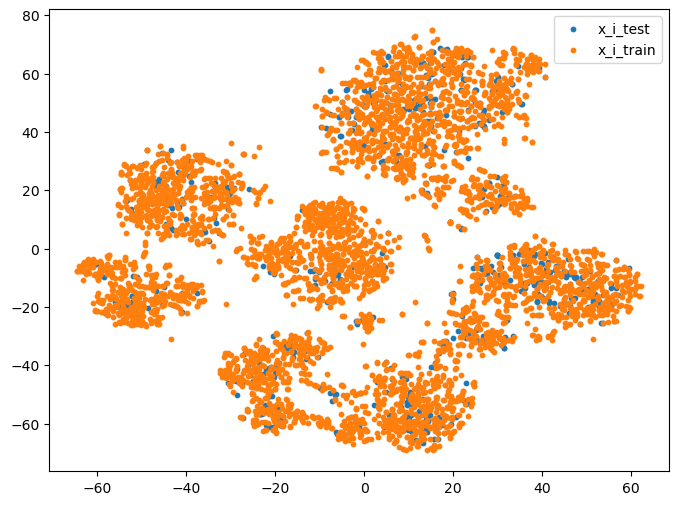

(34000, 18, 512)
(34000,)
Final X shape: (5000, 9216)


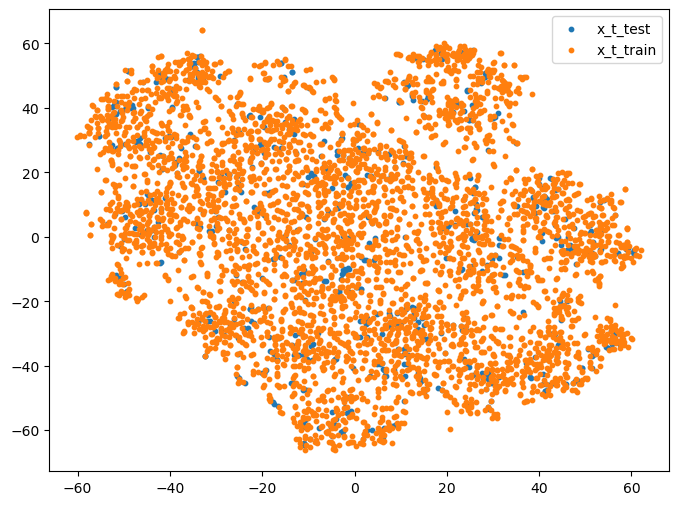

In [36]:
plot_embs(emb_dict=normal_images, pca_dim=512, sample=5000)
plot_embs(emb_dict=normal_tabular, pca_dim=2048, sample=5000)

In [37]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/black"
normal_train_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="train", raw=True)
normal_test_raw = get_embeddings(dataset_dir_path=dataset_dir_path, split="test", raw=True)

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


In [38]:
normal_train_raw_new = {k+"_train": v for k, v in normal_train_raw.items()}
normal_test_raw_new = {k+"_test": v for k, v in normal_test_raw.items()}

In [39]:
normal_images = {"x_i_train": normal_train_raw_new["x_i_train"], "x_i_test": normal_test_raw_new["x_i_test"]}
normal_tabular = {"x_t_train": normal_train_raw_new["x_t_train"], "x_t_test": normal_test_raw_new["x_t_test"]}

(33992, 16, 2048)
(33992,)
Final X shape: (5000, 32768)


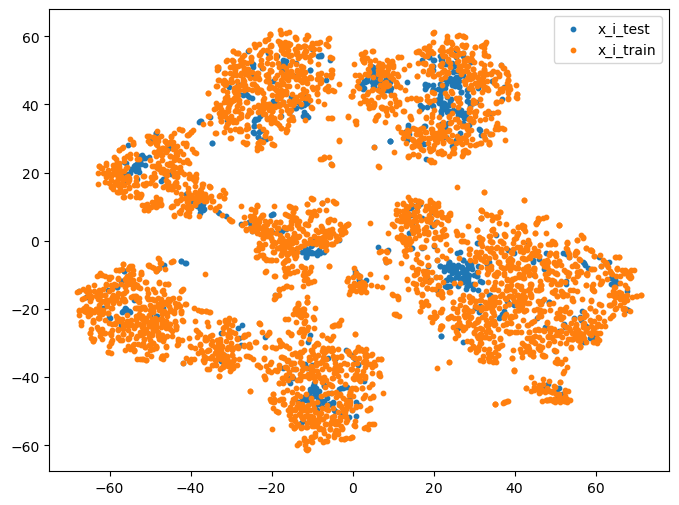

(33992, 18, 512)
(33992,)
Final X shape: (5000, 9216)


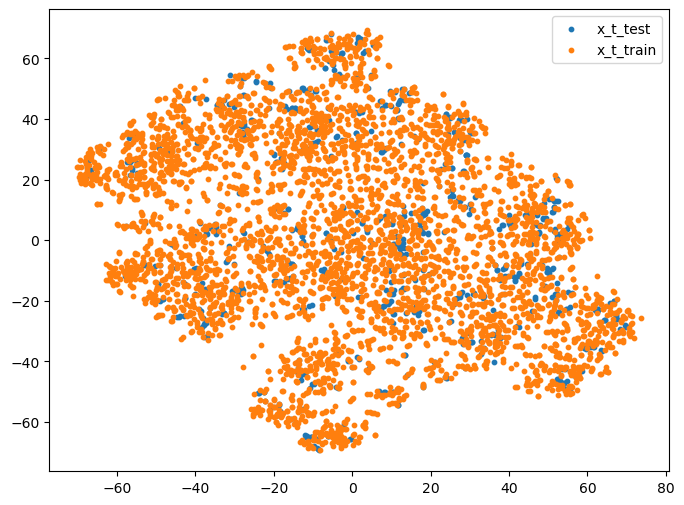

In [40]:
plot_embs(emb_dict=normal_images, pca_dim=512, sample=5000)
plot_embs(emb_dict=normal_tabular, pca_dim=2048, sample=5000)

(15000, 512)
(15000,)
Final X shape: (15000, 512)


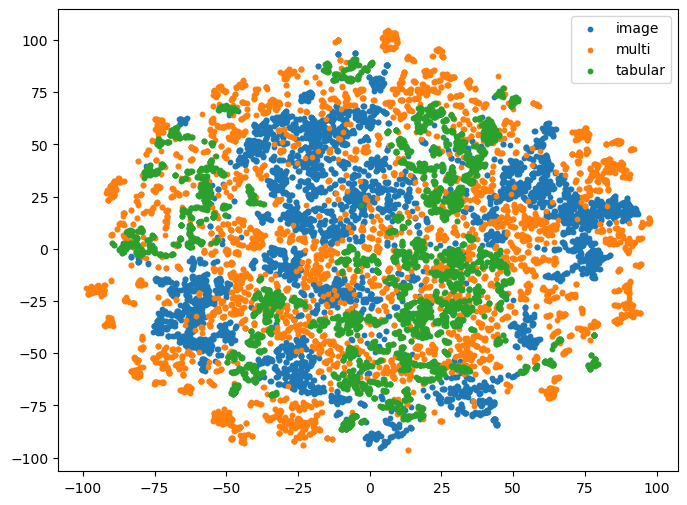

In [41]:
test = normal_test_emb_concat_dict | normal_test_emb_concat_dict
plot_embs(emb_dict=test, pca_dim=512, sample=25000)
#plot_embs(emb_dict=normal_train_emb_concat_dict, pca_dim=512, sample=25000)
#plot_embs(emb_dict=normal_test_emb_concat_dict, pca_dim=512, sample=25000)

(145000, 512)
(145000,)
(50000, 512)
PCA shape: (50000, 512)


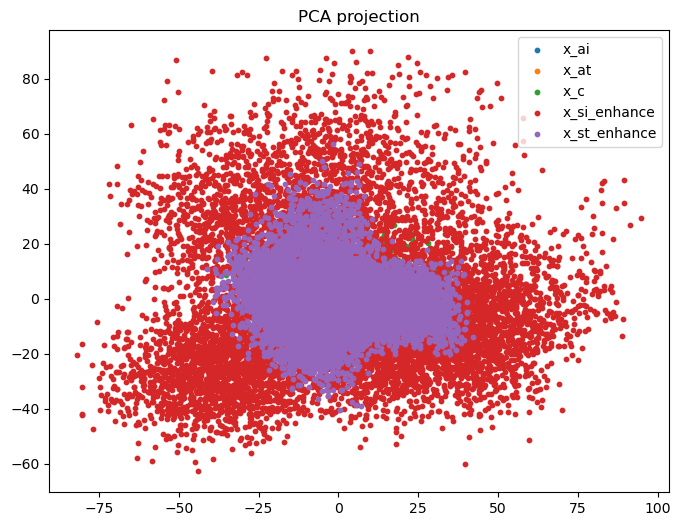

(25000, 512)
(25000,)
(25000, 512)
PCA shape: (25000, 512)


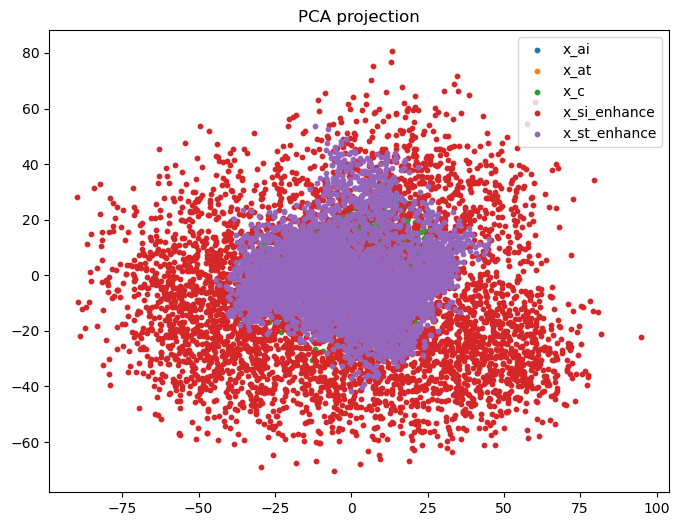

(87000, 512)
(87000,)
(50000, 512)
PCA shape: (50000, 512)


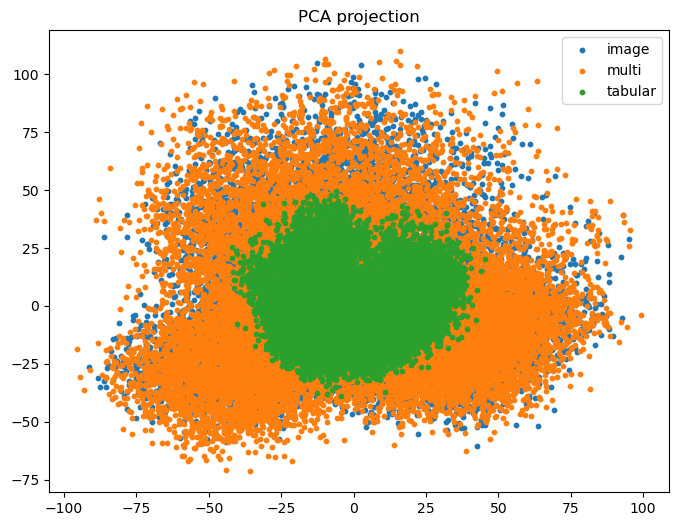

(15000, 512)
(15000,)
(15000, 512)
PCA shape: (15000, 512)


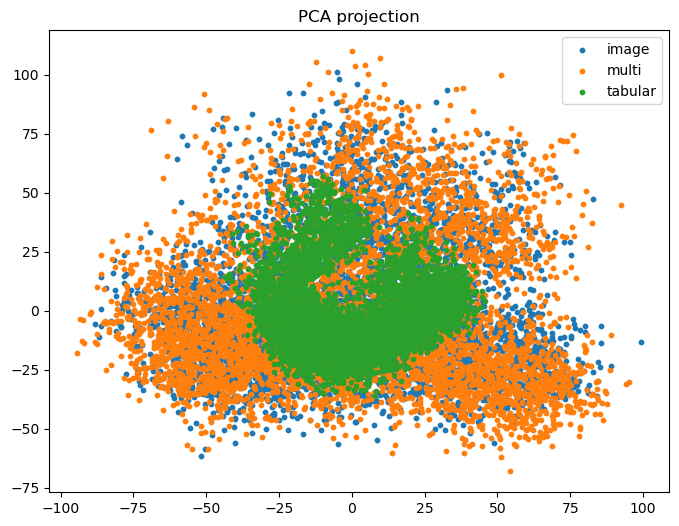

In [44]:
plot_pca(emb_dict=normal_train_emb_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=normal_test_emb_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=normal_train_emb_concat_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=normal_test_emb_concat_dict, pca_dim=512, sample=50000)

In [9]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/black"
black_train_emb_dict, black_train_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="train")
black_test_emb_dict, black_test_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="test")

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


(145000, 512)
(145000,)
Final X shape: (25000, 512)


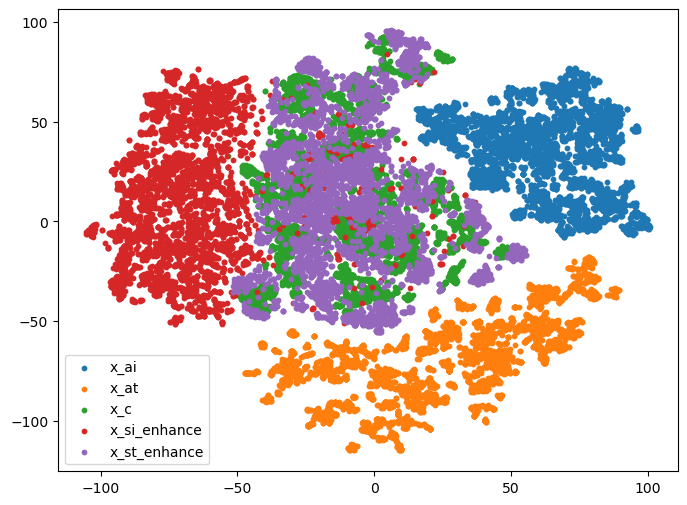

(24960, 512)
(24960,)
Final X shape: (24960, 512)


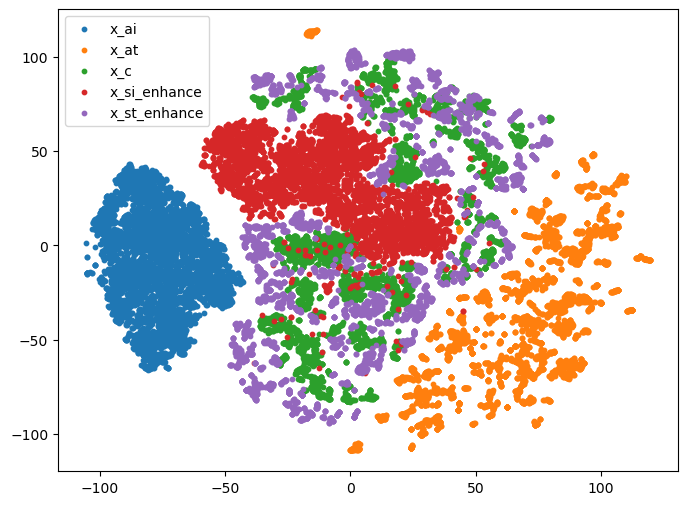

In [10]:
plot_embs(emb_dict=black_train_emb_dict, pca_dim=512, sample=25000)
plot_embs(emb_dict=black_test_emb_dict, pca_dim=512, sample=25000)

(87000, 512)
(87000,)
Final X shape: (25000, 512)


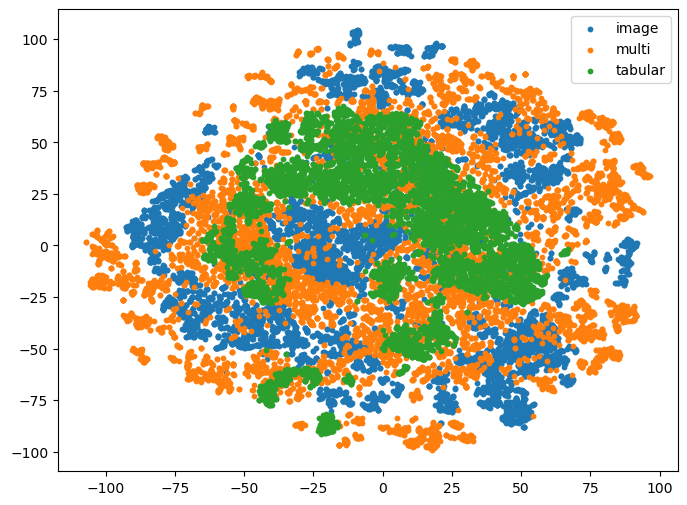

(14976, 512)
(14976,)
Final X shape: (14976, 512)


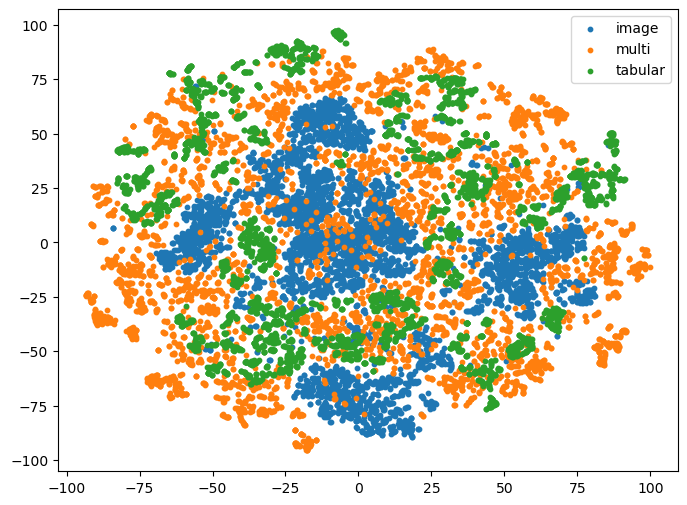

In [11]:
plot_embs(emb_dict=black_train_emb_concat_dict, pca_dim=512, sample=25000)
plot_embs(emb_dict=black_test_emb_concat_dict, pca_dim=512, sample=25000)

(145000, 512)
(145000,)
(145000, 512)
PCA shape: (145000, 512)


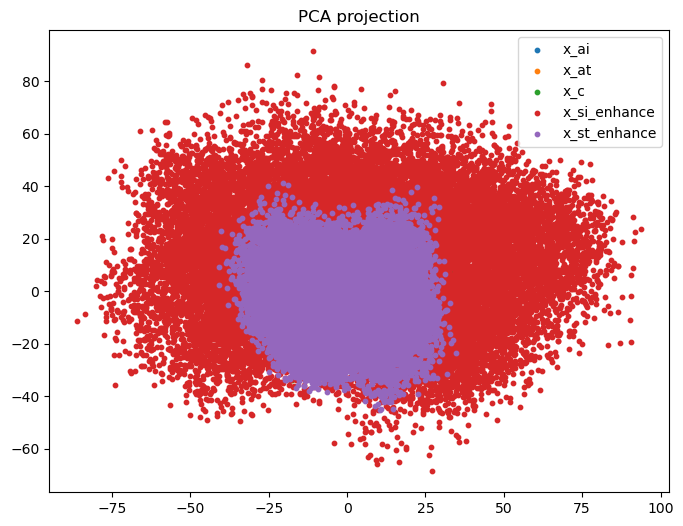

(24960, 512)
(24960,)
(24960, 512)
PCA shape: (24960, 512)


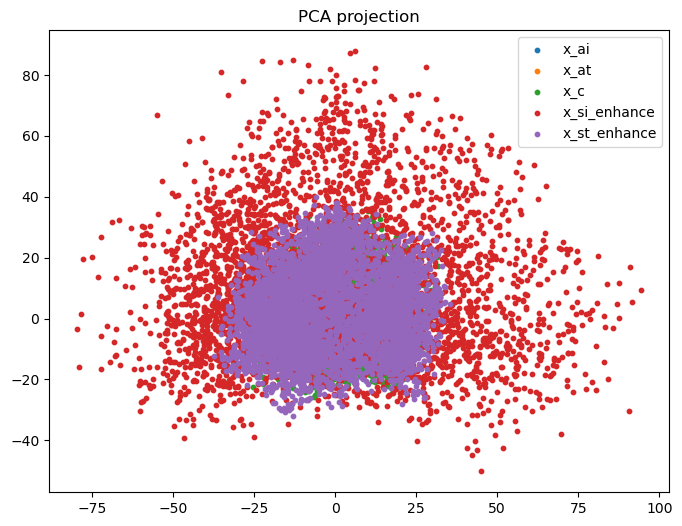

(87000, 512)
(87000,)
(87000, 512)
PCA shape: (87000, 512)


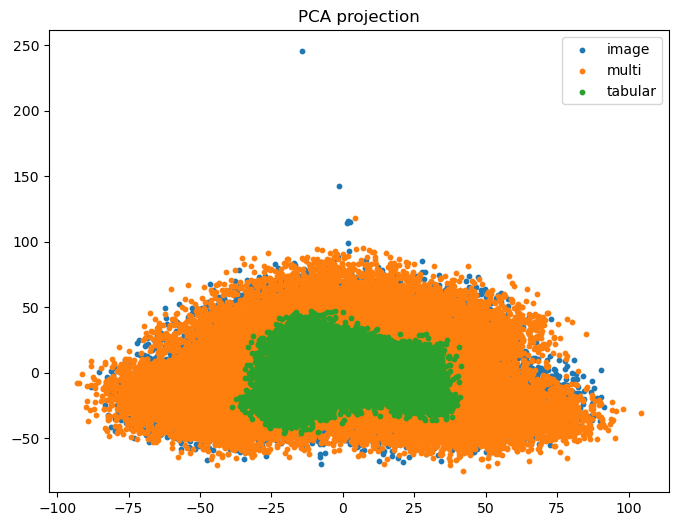

(14976, 512)
(14976,)
(14976, 512)
PCA shape: (14976, 512)


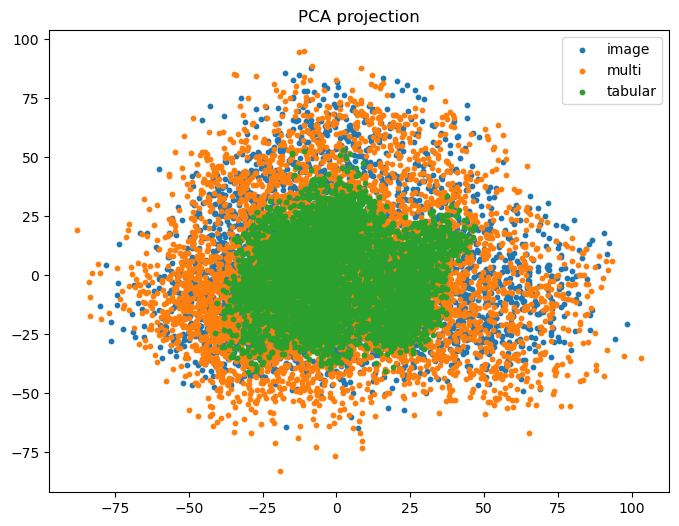

In [46]:
plot_pca(emb_dict=black_train_emb_dict, pca_dim=512)
plot_pca(emb_dict=black_test_emb_dict, pca_dim=512)
plot_pca(emb_dict=black_train_emb_concat_dict, pca_dim=512)
plot_pca(emb_dict=black_test_emb_concat_dict, pca_dim=512)

In [14]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/miles"
miles_train_emb_dict, miles_train_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="train")
miles_test_emb_dict, miles_test_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="test")

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


(145000, 512)
(145000,)
Final X shape: (25000, 512)


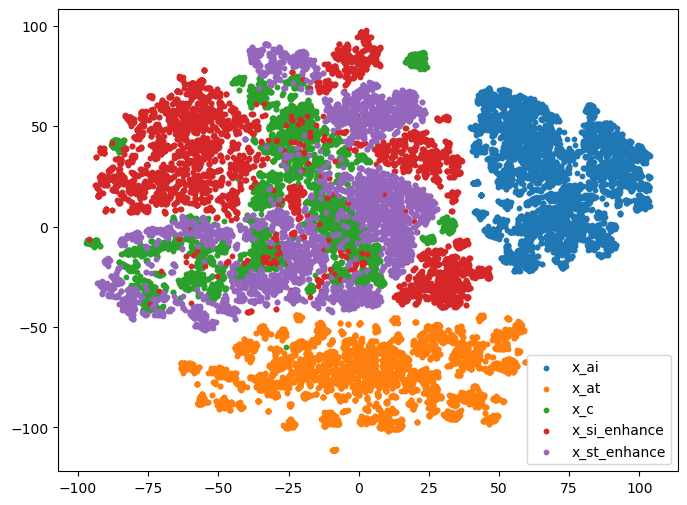

(24660, 512)
(24660,)
Final X shape: (24660, 512)


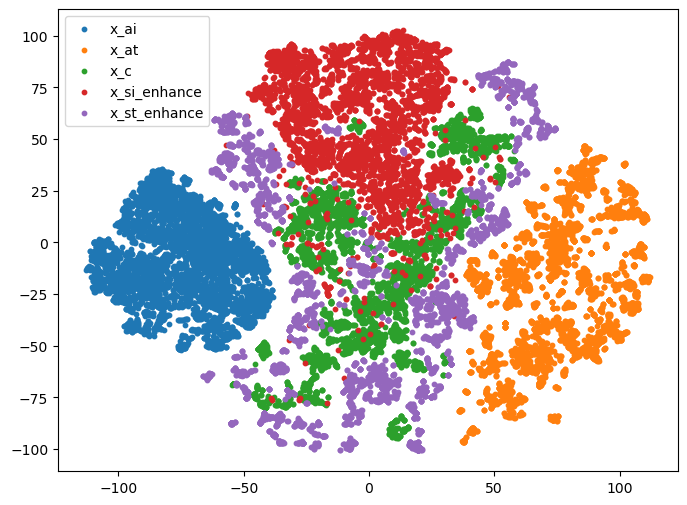

In [15]:
plot_embs(emb_dict=miles_train_emb_dict, pca_dim=512, sample=25000)
plot_embs(emb_dict=miles_test_emb_dict, pca_dim=512, sample=25000)

(87000, 512)
(87000,)
Final X shape: (25000, 512)


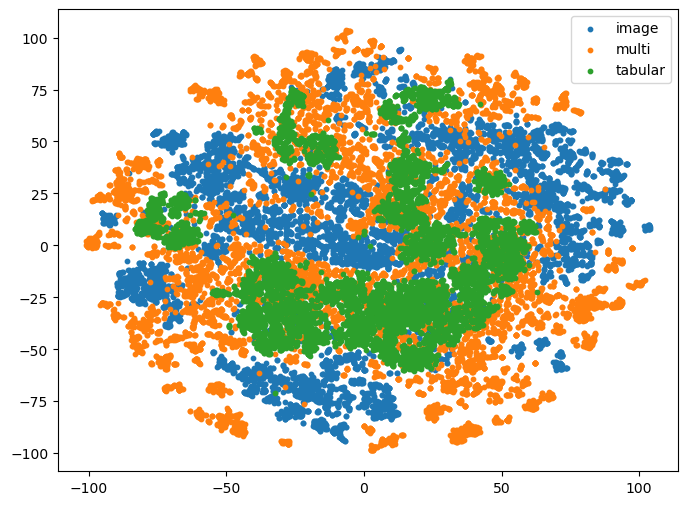

(14796, 512)
(14796,)
Final X shape: (14796, 512)


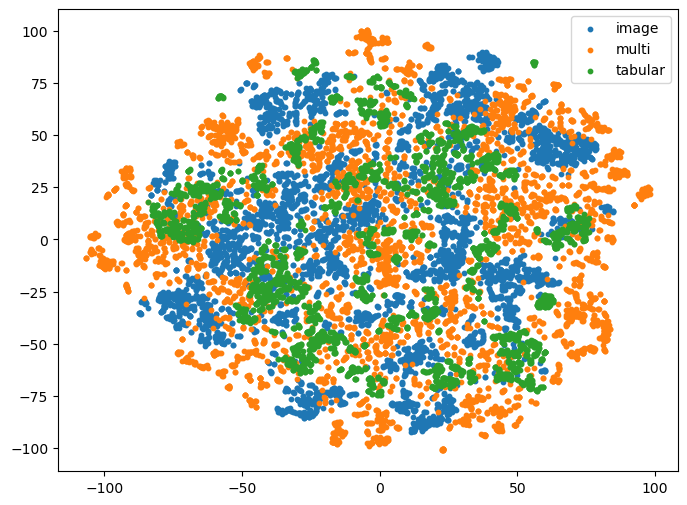

In [16]:
plot_embs(emb_dict=miles_train_emb_concat_dict, pca_dim=512, sample=25000)
plot_embs(emb_dict=miles_test_emb_concat_dict, pca_dim=512, sample=25000)

(145000, 512)
(145000,)
(50000, 512)
PCA shape: (50000, 512)


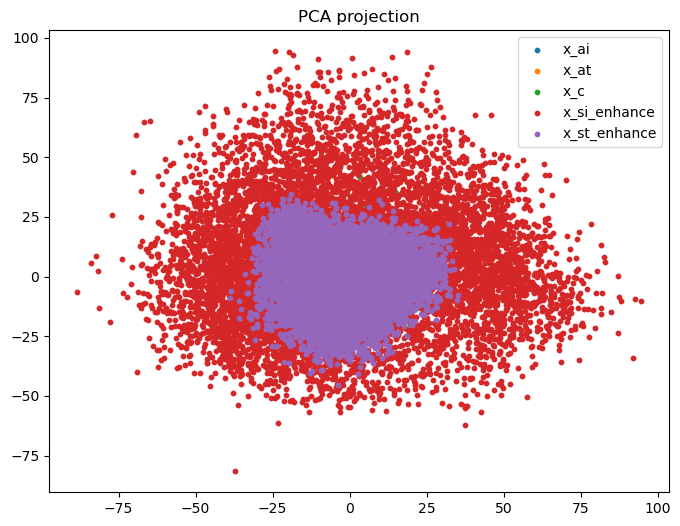

(24660, 512)
(24660,)
(24660, 512)
PCA shape: (24660, 512)


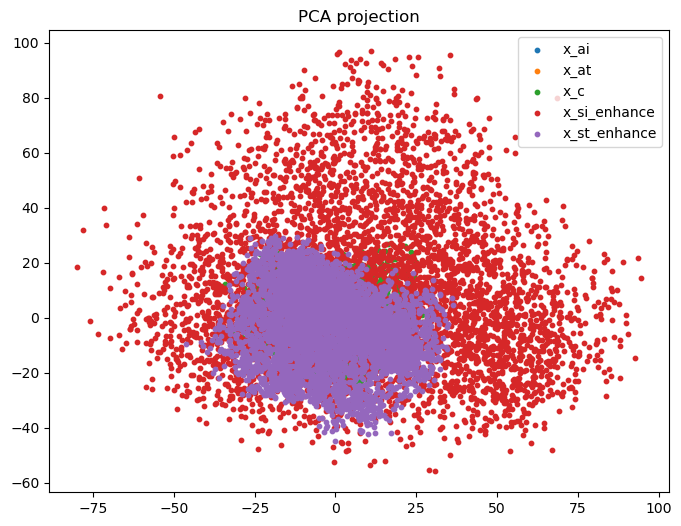

(87000, 512)
(87000,)
(50000, 512)
PCA shape: (50000, 512)


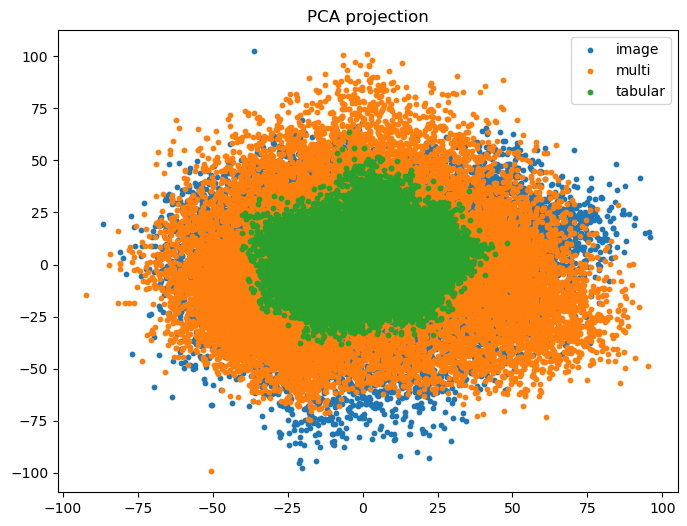

(14796, 512)
(14796,)
(14796, 512)
PCA shape: (14796, 512)


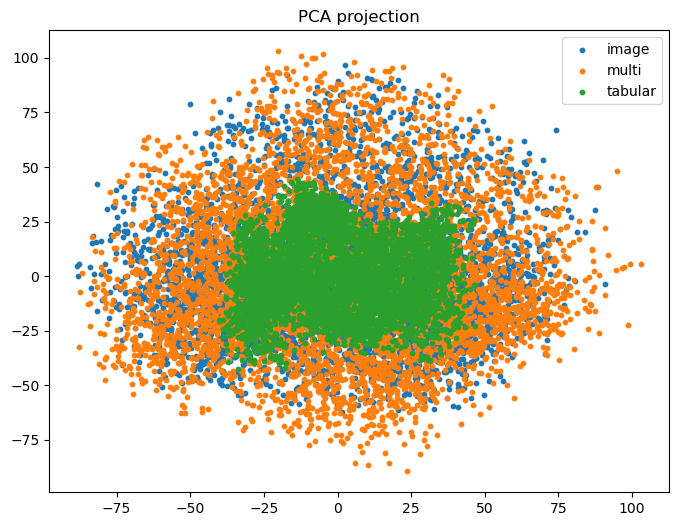

In [42]:
plot_pca(emb_dict=miles_train_emb_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=miles_test_emb_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=miles_train_emb_concat_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=miles_test_emb_concat_dict, pca_dim=512, sample=50000)

In [17]:
dataset_dir_path = "/data/local/kgutjahr/datasets/DVM/shifted_dists/too_small/bw_miles"
bw_train_emb_dict, bw_train_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="train")
bw_test_emb_dict, bw_test_emb_concat_dict = get_embeddings(dataset_dir_path=dataset_dir_path, split="test")

Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention
Using dvm transform for hard eval augmentation
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
Using dvm transform for hard eval augmentation
Using dvm transform for default transform
TabularTransformerEncoder uses Mask Attention


(145000, 512)
(145000,)
Final X shape: (25000, 512)


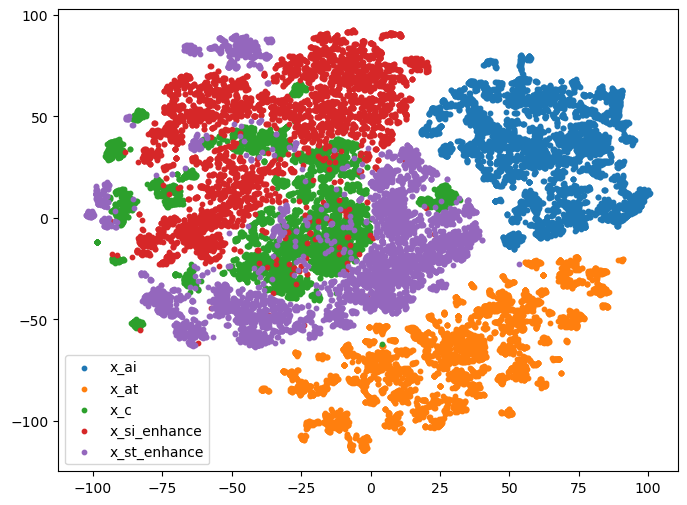

(24690, 512)
(24690,)
Final X shape: (24690, 512)


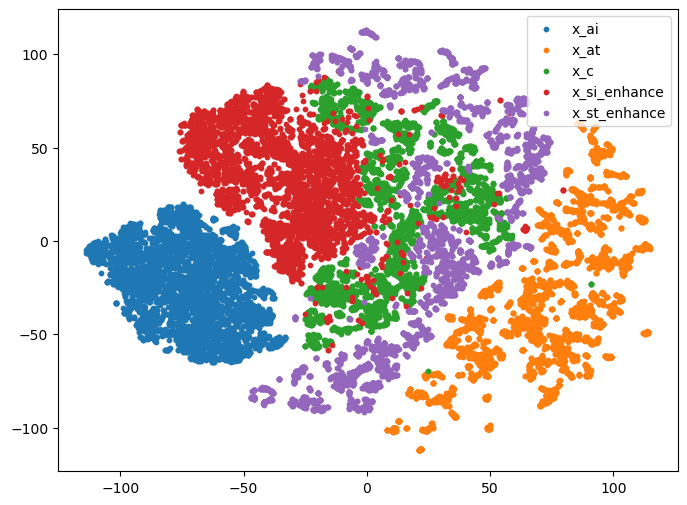

In [18]:
plot_embs(emb_dict=bw_train_emb_dict, pca_dim=512, sample=25000)
plot_embs(emb_dict=bw_test_emb_dict, pca_dim=512, sample=25000)

(87000, 512)
(87000,)
Final X shape: (25000, 512)


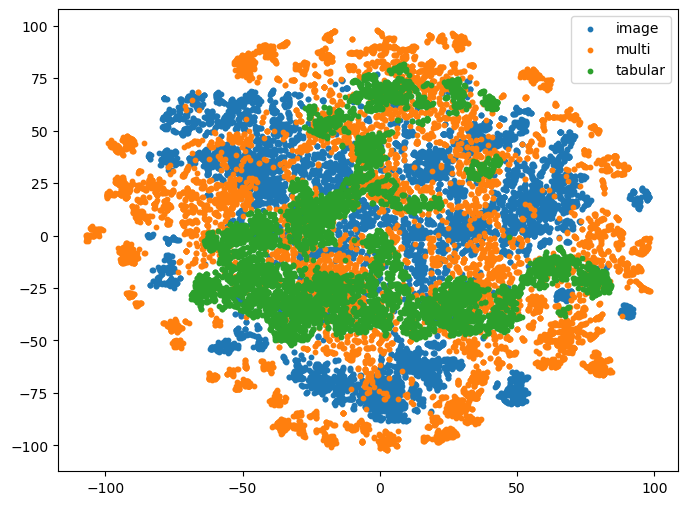

(14814, 512)
(14814,)
Final X shape: (14814, 512)


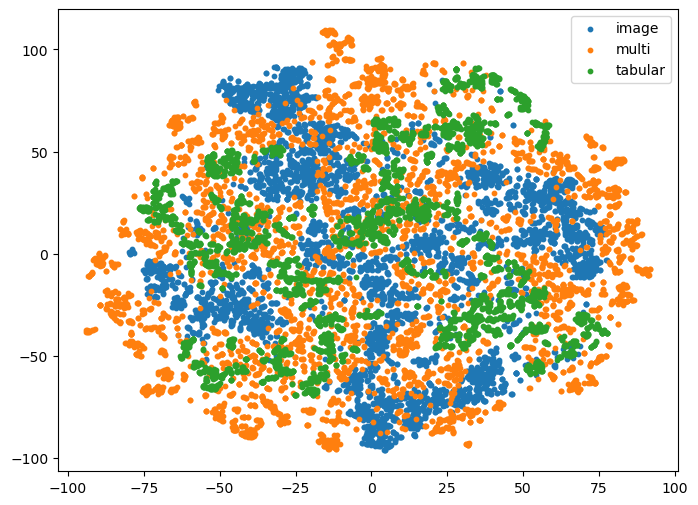

In [19]:
plot_embs(emb_dict=bw_train_emb_concat_dict, pca_dim=512, sample=25000)
plot_embs(emb_dict=bw_test_emb_concat_dict, pca_dim=512, sample=25000)

(145000, 512)
(145000,)
(50000, 512)
PCA shape: (50000, 512)


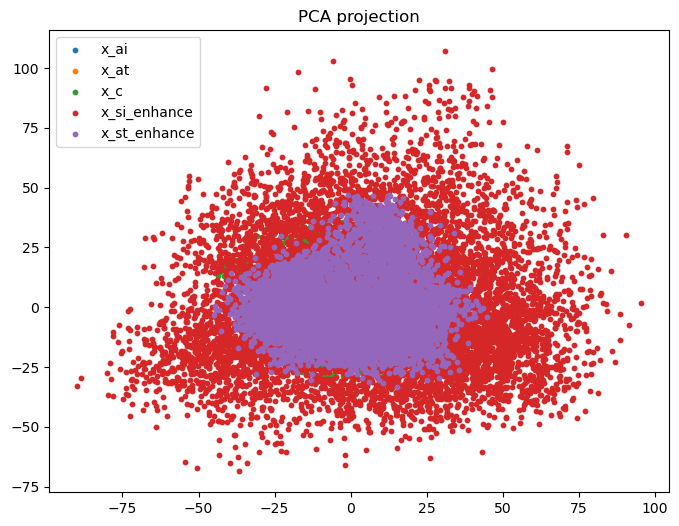

(24690, 512)
(24690,)
(24690, 512)
PCA shape: (24690, 512)


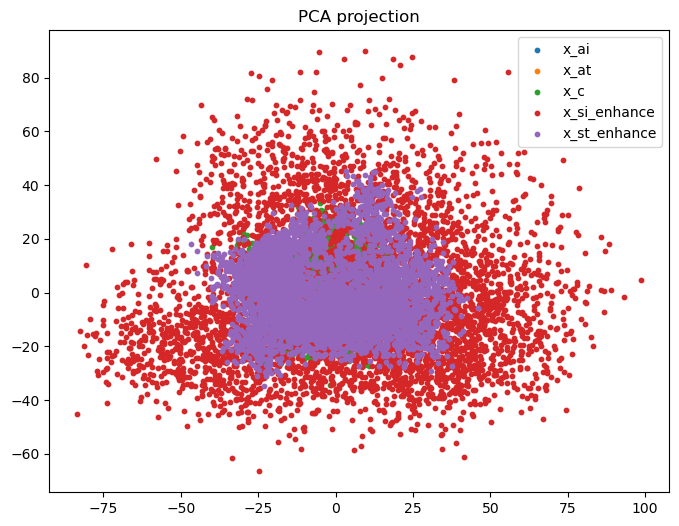

(87000, 512)
(87000,)
(50000, 512)
PCA shape: (50000, 512)


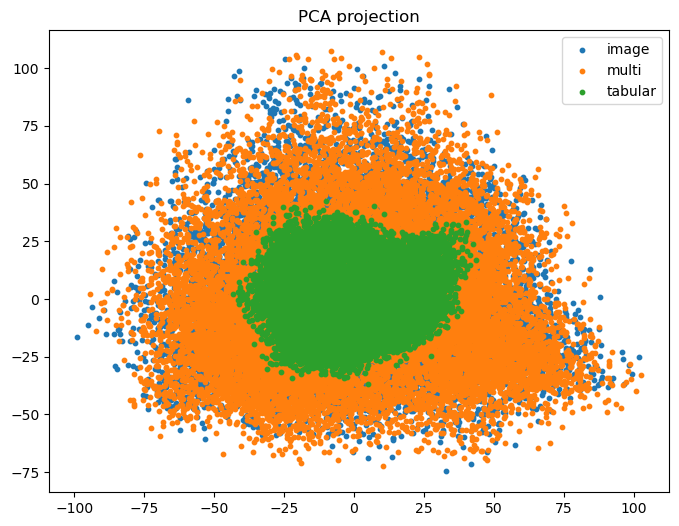

(14814, 512)
(14814,)
(14814, 512)
PCA shape: (14814, 512)


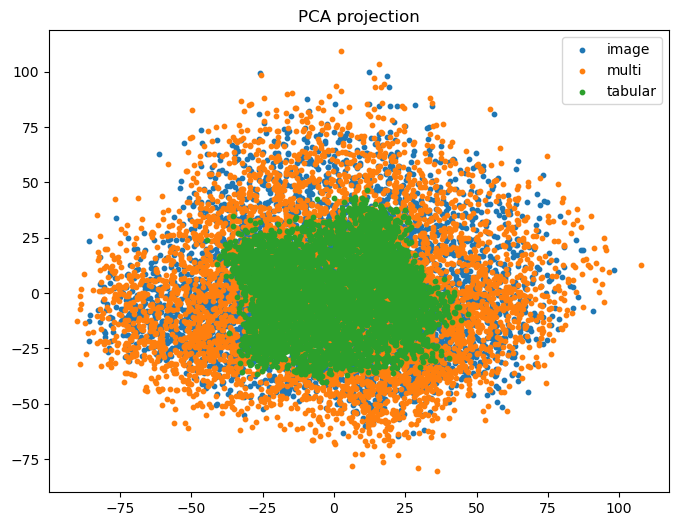

In [45]:
plot_pca(emb_dict=bw_train_emb_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=bw_test_emb_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=bw_train_emb_concat_dict, pca_dim=512, sample=50000)
plot_pca(emb_dict=bw_test_emb_concat_dict, pca_dim=512, sample=50000)